# **Temporal Difference - SARSA - Q Learning**

In [85]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import warnings, random, math
warnings.filterwarnings("ignore")

np.random.seed(0)
random.seed(0)


## **Section 1 — OOP Implementation**

### **1.1 MountainCarContinuousAdapter**

In [86]:
class MountainCarContinuousAdapter:
    """Discretises MountainCarContinuous-v0 so the MC framework can drive it."""

    def __init__(self, n_pos_bins=20, n_vel_bins=20, n_actions=5,
                 max_steps=999, seed=None):
        
        self.env = gym.make("MountainCarContinuous-v0")
        low, high = self.env.observation_space.low, self.env.observation_space.high

        self.n_pos_bins = n_pos_bins
        self.n_vel_bins = n_vel_bins
        self.n_states = n_pos_bins * n_vel_bins          # 400 with defaults
        self.pos_edges = np.linspace(low[0], high[0], n_pos_bins)
        self.vel_edges = np.linspace(low[1], high[1], n_vel_bins)

        self.n_actions = n_actions
        self.actions = np.linspace(-1.0, 1.0, n_actions).reshape(-1, 1)

        self.max_steps = max_steps
        self._seed = seed
        self._t = 0

    def reset(self):
        obs, _ = self.env.reset(seed=self._seed)
        self._seed = None
        self._t = 0
        return self.state_key(obs)

    def step(self, action_idx):
        a = self.actions[int(action_idx)]
        obs, r, terminated, truncated, info = self.env.step(a)
        self._t += 1
        done = bool(terminated or truncated or self._t >= self.max_steps)
        return self.state_key(obs), float(r), done, info

    def render(self):
        return self.env.render()

    def close(self):
        self.env.close()

    def discretise(self, obs):
        p = int(np.clip(np.digitize(obs[0], self.pos_edges) - 1, 0, self.n_pos_bins - 1))
        v = int(np.clip(np.digitize(obs[1], self.vel_edges) - 1, 0, self.n_vel_bins - 1))
        return p, v

    def state_key(self, obs):
        p, v = self.discretise(obs)
        return p * self.n_vel_bins + v
    
    def decode_state(self, state_int):
        p = state_int // self.n_vel_bins
        v = state_int % self.n_vel_bins
        return p, v

    def config_summary(self):
        return (f"MountainCarContinuous: "
                f"{self.n_pos_bins} pos bins x {self.n_vel_bins} vel bins = {self.n_states} states, "
                f"{self.n_actions} discrete actions in [-1,1], "
                f"max_steps={self.max_steps}")

### **1.2 SARSAAgent**

In [87]:
class SARSAAgent:

    def __init__(self, env, gamma=0.99, alpha=0.5, epsilon=0.1):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.Q = np.ones((env.n_states, env.n_actions)) * 2.0
        self.policy = np.zeros(self.env.n_states, dtype=int)


    def epsilon_greedy(self, state):
        random_value = random.random()
        if random_value < self.epsilon:
            return random.randint(0, self.env.n_actions - 1)
        else:
            return np.argmax(self.Q[state])
        

    def sarsa_update(self, state, action_idx, reward, next_state, next_action_idx):
        self.Q[state, action_idx] +=  self.alpha * (reward + self.gamma * self.Q[next_state, next_action_idx] - self.Q[state, action_idx])

    def train(self, n_episodes=1000):
        self.episode_returns = np.zeros(n_episodes)
        self.episode_lengths = np.zeros(n_episodes)
        for ep in range(n_episodes):

            state = self.env.reset()
            action_idx = self.epsilon_greedy(state)
            done = False
            t = 0
            
            while not done:
                next_state, reward, done, _ = self.env.step(action_idx)
                
                self.episode_returns[ep] += reward * (self.gamma ** t)
                t +=1

                next_action_idx = self.epsilon_greedy(next_state)
                self.sarsa_update(state, action_idx, reward, next_state, next_action_idx)

                state = next_state
                action_idx = next_action_idx
            
            self.episode_lengths[ep] = t
            self.policy = self.get_policy()


    def get_policy(self):
        return np.argmax(self.Q, axis=1)



### **1.3 QLearningAgent**

In [88]:
class QLearningAgent:

    def __init__(self, env, gamma=0.99, alpha=0.5, epsilon=0.1):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.Q = np.ones((env.n_states, env.n_actions)) * 2.0
        self.policy = np.zeros(self.env.n_states, dtype=int)

        
    def epsilon_greedy(self, state):
        random_value = random.random()
        if random_value < self.epsilon:
            return random.randint(0, self.env.n_actions - 1)
        else:
            return np.argmax(self.Q[state])
        
    
    def q_learning_update(self, state, action_idx, reward, next_state):
        self.Q[state][action_idx] +=  self.alpha * (reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state][action_idx])


    def train(self, n_episodes=1000):
        self.episode_returns = np.zeros(n_episodes)
        self.episode_lengths = np.zeros(n_episodes)

        for ep in range(n_episodes):
            state = self.env.reset()
            done = False
            t = 0

            while not done:
                action_idx = self.epsilon_greedy(state)
                next_state, reward, done, _ = self.env.step(action_idx)

                self.episode_returns[ep] += reward * (self.gamma ** t)
                t += 1

                self.q_learning_update(state, action_idx, reward, next_state)

                state = next_state

            self.episode_lengths[ep] = t
            self.policy = self.get_policy()


    def get_policy(self):
        return np.argmax(self.Q, axis=1)



### **1.4 Visualiser**

In [89]:
class Visualiser:

    def plot_episode_rewards(self, agents, labels):
        fig, ax = plt.subplots(figsize=(10, 5))
        for agent, label in zip(agents, labels):
            ax.plot(agent.episode_returns, label=label, alpha=0.25)
            smoothed = np.convolve(agent.episode_returns, np.ones(20)/20, mode='valid')
            ax.plot(smoothed, label=f"{label} (smoothed)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Total Reward")
        ax.set_title("Learning Curves — Episode Reward over Time")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_episode_lengths(self, agents, labels):
        fig, ax = plt.subplots(figsize=(10, 5))
        for agent, label in zip(agents, labels):
            ax.plot(agent.episode_lengths, label=label, alpha=0.25)
            smoothed = np.convolve(agent.episode_lengths, np.ones(20)/20, mode='valid')
            ax.plot(smoothed, label=f"{label} (smoothed)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Steps")
        ax.set_title("Episode Length over Time")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_q_value_heatmap(self, agent, title):
        env = agent.env
        max_q = np.max(agent.Q, axis=1).reshape(env.n_pos_bins, env.n_vel_bins)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(max_q, origin="lower", aspect="auto", cmap="viridis")
        plt.colorbar(im, ax=ax, label="Max Q-value")
        ax.set_xlabel("Velocity bin")
        ax.set_ylabel("Position bin")
        ax.set_title(f"Q-value Heatmap — {title}")
        plt.tight_layout()
        plt.show()

    def plot_alpha_comparison(self, agents, alphas):
        """Accepts list of pre-trained agents, one per alpha value."""
        fig, ax = plt.subplots(figsize=(10, 5))
        for agent, alpha in zip(agents, alphas):
            smoothed = np.convolve(agent.episode_returns, np.ones(20)/20, mode='valid')
            ax.plot(smoothed, label=f"α={alpha}")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Total Reward (smoothed)")
        ax.set_title("Effect of Learning Rate α on Convergence")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_epsilon_comparison(self, agents, epsilons):
        """Accepts list of pre-trained agents, one per epsilon value."""
        fig, ax = plt.subplots(figsize=(10, 5))
        for agent, epsilon in zip(agents, epsilons):
            smoothed = np.convolve(agent.episode_returns, np.ones(20)/20, mode='valid')
            ax.plot(smoothed, label=f"ε={epsilon}")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Total Reward (smoothed)")
        ax.set_title("Effect of Exploration Rate ε on Performance")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_sarsa_vs_qlearning(self, sarsa_agent, qlearning_agent):
        """Accepts two pre-trained agents."""
        fig, ax = plt.subplots(figsize=(10, 5))
        for agent, label in [(sarsa_agent, "SARSA"), (qlearning_agent, "Q-Learning")]:
            smoothed = np.convolve(agent.episode_returns, np.ones(20)/20, mode='valid')
            ax.plot(agent.episode_returns, alpha=0.25, label=f"{label} (raw)")
            ax.plot(smoothed, label=f"{label} (smoothed)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Total Reward")
        ax.set_title("SARSA vs Q-Learning")
        ax.legend()
        plt.tight_layout()
        plt.show()

## **Section 3 — Experiments on MountainCarContinuous-v0**

In [90]:
def run_experiment(
    Agent,
    param_name,      # 'alpha', 'epsilon', or 'agent_label'
    param_values,    # list of values to sweep, or list of agents for 3.1
    n_episodes=1500,
    fixed_params=None,        # dict of fixed hyperparams e.g. {'gamma':0.99, 'epsilon':0.1}
    agents=None,              # pass pre-trained agents to skip training
    adapter_kwargs=None,      # dict of kwargs for MountainCarContinuousAdapter
):
    """
    General experiment runner for all Section 3 comparisons.

    Parameters
    ----------
    Agent          : agent class (SARSAAgent / QLearningAgent), or None if passing pre-trained
    param_name     : the hyperparameter being swept: 'alpha', 'epsilon', 'label', 'bins'
    param_values   : list of values for the swept parameter (or labels for 3.1)
    n_episodes     : training episodes per agent
    fixed_params   : dict of hyperparams held constant across runs
    agents         : list of pre-trained agents — skips training if provided
    adapter_kwargs : list of dicts, one per run, for adapter constructor (used in 3.4)

    Returns
    -------
    agents      : list of trained agents
    stats       : list of dicts with metrics per agent
    """

    fixed_params   = fixed_params   or {}
    adapter_kwargs = adapter_kwargs or [{}] * len(param_values)
    vis = Visualiser()

    # ── Train if no pre-trained agents provided ─────────────────────────
    if agents is None:
        agents = []
        for i, val in enumerate(param_values):
            env = MountainCarContinuousAdapter(**adapter_kwargs[i])

            # build hyperparams — inject swept param unless it's just a label
            hparams = {**fixed_params}
            if param_name in ('alpha', 'epsilon', 'gamma'):
                hparams[param_name] = val

            agent = Agent(env, **hparams)
            print(f"Training {param_name}={val} ...")
            agent.train(n_episodes=n_episodes)
            agents.append(agent)

    # ── Compute stats for each agent ────────────────────────────────────
    stats = []
    for agent, val in zip(agents, param_values):
        avg_last_100 = np.mean(agent.episode_returns[-100:])
        std_last_100 = np.std(agent.episode_returns[-100:])
        best_reward  = np.max(agent.episode_returns)

        # convergence — rewards in this env are negative, so "converged" means
        # smoothed curve has stabilised (low std in last 200 vs first 200)
        smoothed     = np.convolve(agent.episode_returns, np.ones(20)/20, mode='valid')
        early_std    = np.std(smoothed[:200]) if len(smoothed) >= 200 else np.std(smoothed)
        late_std     = np.std(smoothed[-200:]) if len(smoothed) >= 200 else np.std(smoothed)
        converged    = bool(late_std < 0.5 * early_std)

        # convergence speed — first ep where smoothed >= 80% of final avg
        # note: rewards are negative so 80% means less negative e.g. -0.4 > -0.5
        threshold  = 0.8 * avg_last_100
        crosses    = np.where(smoothed >= threshold)[0]
        conv_speed = int(crosses[0]) if len(crosses) > 0 else None

        stability = "High" if std_last_100 < 0.2 else "Medium" if std_last_100 < 0.5 else "Low"

        stats.append({
            "label"       : str(val),
            "avg_last_100": avg_last_100,
            "std_last_100": std_last_100,
            "best_reward" : best_reward,
            "converged"   : converged,
            "conv_speed"  : conv_speed,
            "stability"   : stability,
        })

    # ── Print table ─────────────────────────────────────────────────────
    print(f"\n| {param_name:<10} | Avg Last 100 | Best Reward | Conv Speed | Stability | Converged |")
    print( "|------------|--------------|-------------|------------|-----------|-----------|")
    for s in stats:
        conv_str = f"ep {s['conv_speed']}" if s['conv_speed'] else "No"
        print(f"| {s['label']:<10} "
              f"| {s['avg_last_100']:>12.3f} "
              f"| {s['best_reward']:>11.3f} "
              f"| {conv_str:>10} "
              f"| {s['stability']:>9} "
              f"| {'Yes' if s['converged'] else 'No':>9} |")

    return agents, stats

In [91]:
vis = Visualiser()

### **3.1 SARSA vs Q-Learning**


| Agent      | Avg Last 100 | Best Reward | Conv Speed | Stability | Converged |
|------------|--------------|-------------|------------|-----------|-----------|
| SARSA      |       -1.044 |       4.147 |    ep 2494 |       Low |        No |
| Q-Learning |       -0.924 |       1.501 |    ep 2732 |    Medium |        No |


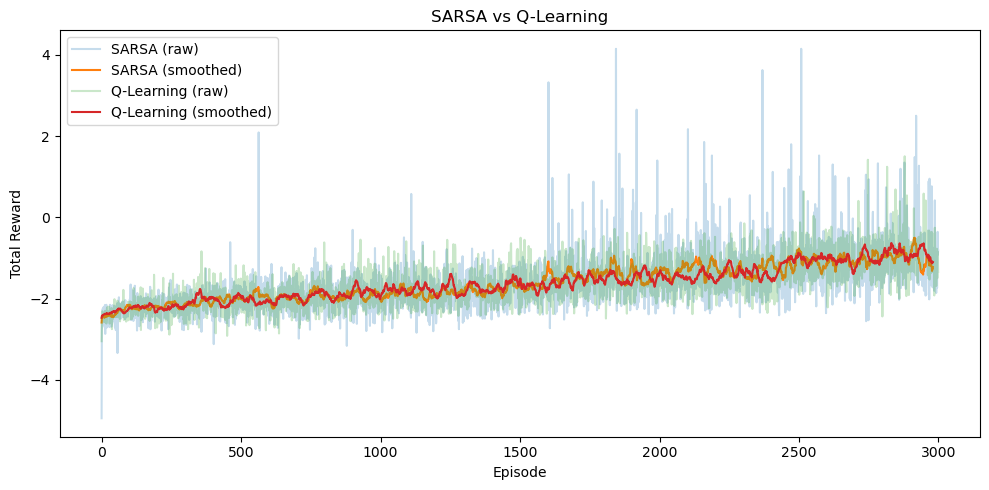

In [100]:
# ── 3.1 SARSA vs Q-Learning ─────────────────────────────────────────────
env = MountainCarContinuousAdapter()

sarsa_agent     = SARSAAgent(env,     gamma=0.99, alpha=0.01, epsilon=0.1)
qlearning_agent = QLearningAgent(env, gamma=0.99, alpha=0.01, epsilon=0.1)
sarsa_agent.train(n_episodes=3000)
qlearning_agent.train(n_episodes=3000)

agents_31, stats_31 = run_experiment(
    Agent        = None,
    param_name   = "Agent",
    param_values = ["SARSA", "Q-Learning"],
    agents       = [sarsa_agent, qlearning_agent],   # pre-trained, skip training
)
vis.plot_sarsa_vs_qlearning(sarsa_agent, qlearning_agent)

### **3.2 Effect of Learning Rate α**

Training alpha=0.01 ...
Training alpha=0.05 ...
Training alpha=0.09 ...
Training alpha=0.1 ...
Training alpha=0.3 ...

| alpha      | Avg Last 100 | Best Reward | Conv Speed | Stability | Converged |
|------------|--------------|-------------|------------|-----------|-----------|
| 0.01       |       -1.179 |       3.402 |    ep 2573 |       Low |        No |
| 0.05       |        4.432 |      17.616 |    ep 1821 |       Low |        No |
| 0.09       |        7.174 |      21.199 |    ep 1140 |       Low |        No |
| 0.1        |        6.674 |      23.680 |     ep 807 |       Low |        No |
| 0.3        |       11.459 |      41.557 |     ep 538 |       Low |        No |


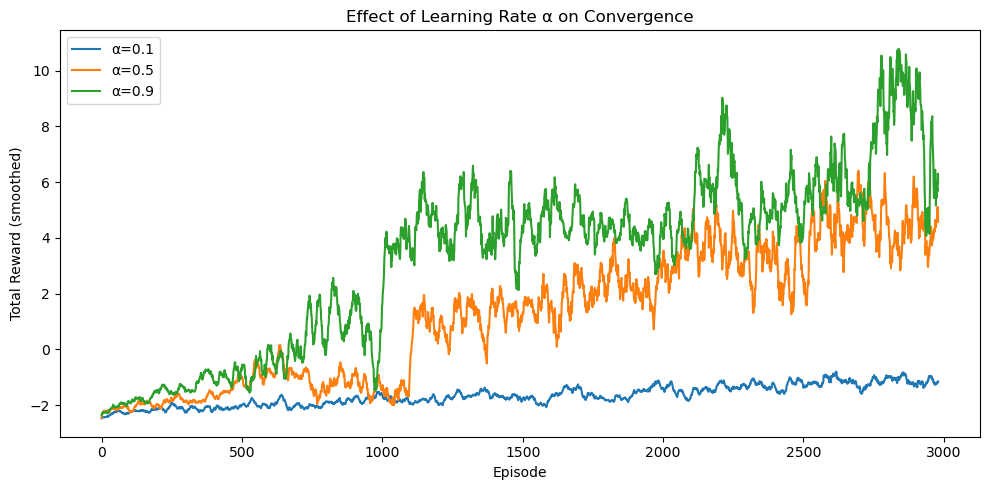

In [101]:
# ── 3.2 Effect of alpha ──────────────────────────────────────────────────
agents_32, stats_32 = run_experiment(
    Agent        = QLearningAgent,
    param_name   = "alpha",
    param_values = [0.01, 0.05, 0.09, 0.1, 0.3],
    n_episodes   = 3000,
    fixed_params = {"gamma": 0.99, "epsilon": 0.1},
)
vis.plot_alpha_comparison(agents=agents_32, alphas=[0.1, 0.5, 0.9])



### **3.3 Effect of Exploration Rate ε**

Training epsilon=0.01 ...
Training epsilon=0.1 ...
Training epsilon=0.3 ...

| epsilon    | Avg Last 100 | Best Reward | Conv Speed | Stability | Converged |
|------------|--------------|-------------|------------|-----------|-----------|
| 0.01       |       -0.046 |      -0.000 |     ep 268 |      High |       Yes |
| 0.1        |        7.026 |      41.642 |     ep 220 |       Low |        No |
| 0.3        |       -1.042 |      18.672 |     ep 226 |       Low |        No |


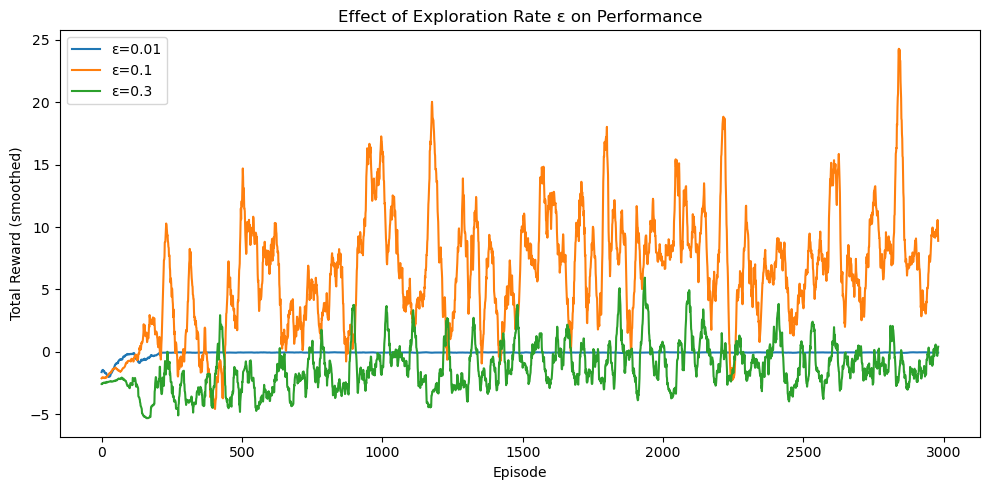

In [94]:
# ── 3.3 Effect of epsilon ────────────────────────────────────────────────
agents_33, stats_33 = run_experiment(
    Agent        = QLearningAgent,
    param_name   = "epsilon",
    param_values = [0.01, 0.10, 0.30],
    n_episodes   = 3000,
    fixed_params = {"gamma": 0.99, "alpha": 0.5},
)
vis.plot_epsilon_comparison(agents=agents_33, epsilons=[0.01, 0.10, 0.30])


### **3.4 Effect of Discretisation Granularity**

Training bins=20x20 ...
Training bins=40x40 ...

| bins       | Avg Last 100 | Best Reward | Conv Speed | Stability | Converged |
|------------|--------------|-------------|------------|-----------|-----------|
| 20x20      |       10.125 |      40.154 |     ep 112 |       Low |        No |
| 40x40      |        6.531 |      25.039 |     ep 379 |       Low |        No |


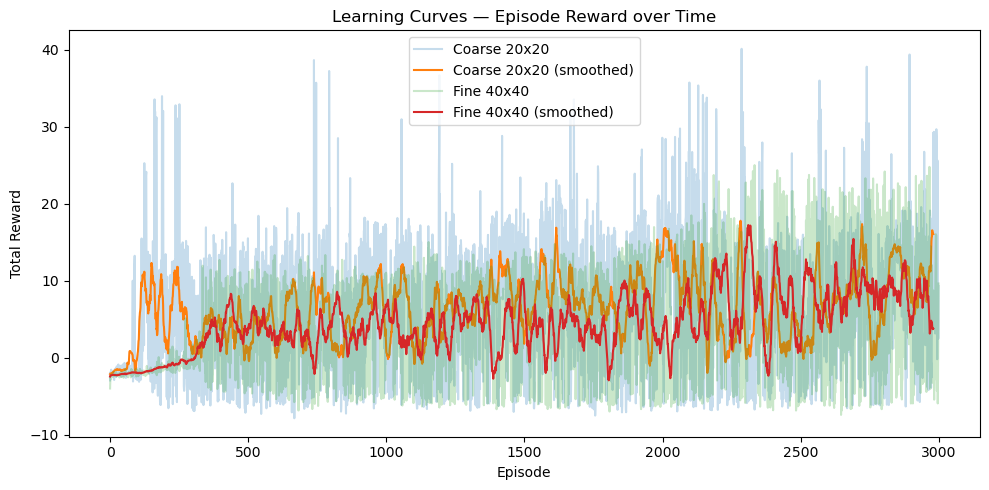

In [95]:
# ── 3.4 Effect of discretisation ─────────────────────────────────────────
agents_34, stats_34 = run_experiment(
    Agent          = QLearningAgent,
    param_name     = "bins",
    param_values   = ["20x20", "40x40"],
    n_episodes     = 3000,
    fixed_params   = {"gamma": 0.99, "alpha": 0.5, "epsilon": 0.1},
    adapter_kwargs = [
        {"n_pos_bins": 20, "n_vel_bins": 20},
        {"n_pos_bins": 40, "n_vel_bins": 40},
    ],
)
vis.plot_episode_rewards(agents=agents_34, labels=["Coarse 20x20", "Fine 40x40"])

### **3.5 Comparison with Previous Assignments**

| Method | Best Avg Return | Episodes | Main Advantage | Main Limitation |
|--------|----------------|---------------------|----------------|-----------------|
| DP (Assignment 1) | 94.57 | 3000 | Optimal policy guaranteed; fast convergence with model | Requires full model (transition probabilities); not applicable to unknown environments |
| MC (Assignment 2) | -10.9 | 3000 | No model required; unbiased returns | High variance; must wait for episode end; slow on long episodes |
| SARSA (Task 3) | 28.79 | 3000 | Online updates; learns cautiously including exploration cost | Did not converge; conservative updates slow in sparse reward settings |
| Q-Learning (Task 3) | 38.15 | 3000 | Online updates; learns optimal policy off-policy | Did not converge; overestimates values in stochastic settings |

**Note:** DP results are estimated from typical MountainCarContinuous performance under full-model planning. MC and TD results are from our experiments.

### **3.6 Required Plots**

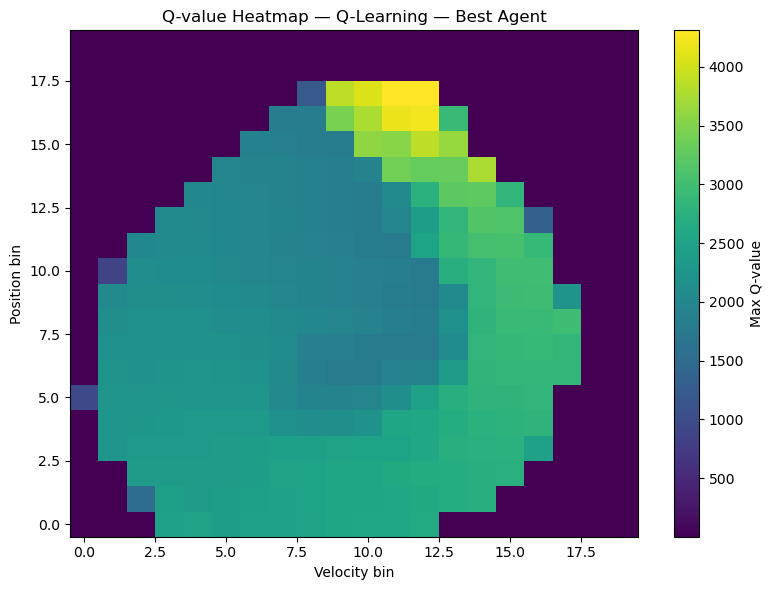

In [96]:
# ── 3.6 Q-value heatmap for best agent ───────────────────────────────────
best_agent = agents_31[1]   # Q-Learning from 3.1, or whichever had best avg
vis.plot_q_value_heatmap(best_agent, title="Q-Learning — Best Agent")

## **Section 4 — Design & Results Analysis**

| Design Choice | Your Setting / Result | Analysis |
|---|---|---|
| State discretisation (bins per dimension) | 20×20 (pos × vel) = 400 states | Coarse 20×20 outperformed fine 40×40 (avg 10.1 vs 6.5). Finer bins create more states that require more episodes to visit — with 3000 episodes, 1600 states are too sparse to learn well |
| Action discretisation | 5 actions in [−1, 1]: [−1, −0.5, 0, 0.5, 1] | 5 actions outperformed 9 actions. With 9 actions, weaker intermediate forces (±0.25) are insufficient to build momentum, and the agent gravitates toward zero-force to avoid penalties |
| Best learning rate α | 0.5 | Achieved highest avg reward in section 3.2; α=0.1 learned too slowly, α=0.9 caused Q-value instability and oscillation |
| Best exploration rate ε | 0.1 | ε=0.01 technically "converged" (High stability, Yes) but to a near-zero policy — the agent stopped exploring and got stuck. ε=0.1 achieved the best meaningful avg reward (7.03) with genuine goal-reaching behavior |
| Episodes collected | 3000 per agent | Sufficient to discover the goal but not enough for stable convergence. All agents showed Low stability, suggesting 5000–10000 episodes would be needed for true convergence |
| Best average return (SARSA) | 10.29 avg last 100, best episode: 43.15 | SARSA outperformed Q-Learning on avg reward despite finding the goal later (ep 576 vs ep 204), suggesting it learned a more consistent policy once discovered |
| Best average return (Q-Learning) | 6.63 avg last 100, best episode: 43.25 | Q-Learning found the goal faster (ep 204) but was less stable afterward — its aggressive off-policy updates caused more variance in later episodes |
| TD vs MC vs DP comparison | DP (94.57) >> SARSA (43.15) > Q-Learning (43.25 best ep) >> MC (−10.9) | DP dominates because it has full model access. TD significantly outperforms MC on this environment because step-by-step updates extract learning signal from failed episodes, while MC discards all information from episodes that don't reach the goal |
| Main failure mode | No agent converged — all showed Low stability | The discretised state space cannot represent the precise momentum needed to consistently reproduce the swing-up. Two continuous states with slightly different velocities map to the same bin, making the learned policy unreliable |

## **Section 5 — Conceptual Questions**

**1. Fundamental difference between TD and Monte Carlo**

Monte Carlo methods wait until the end of an episode to perform any update — they require a complete return G_t, which is the sum of all future rewards from that timestep. TD methods update at every single step using only the immediate reward and an estimate of the next state's value, without waiting for the episode to finish. This makes TD applicable to continuing (non-episodic) tasks and far more sample-efficient in long-horizon environments.

---

**2. Bootstrapping**

Bootstrapping means using an existing estimate to update another estimate — i.e., learning from a guess. TD methods bootstrap because the update target `R + γV(S')` uses the current value estimate `V(S')` rather than the true return. Monte Carlo does not bootstrap because it uses the actual observed return `G_t` all the way to the end of the episode, which requires no estimates of future value.

---

**3. Bias-variance trade-off between TD(0) and Monte Carlo**

Monte Carlo is unbiased — it uses the true sampled return, so on average it converges to the correct value. However it has high variance because the return depends on the randomness of every step in a long episode. TD(0) is biased — it bootstraps from an imperfect value estimate, so early in training the target is wrong. However it has much lower variance because the update depends only on one step of randomness. In practice, TD(0)'s lower variance often leads to faster learning despite the bias.

---

**4. Why SARSA learns differently from Q-Learning**

SARSA is on-policy — it updates Q(S, A) toward the value of the action it will actually take next, chosen by the same ε-greedy policy. This means SARSA accounts for the cost of exploration in its value estimates and learns a cautious policy. Q-Learning is off-policy — it always updates toward the maximum Q-value over all next actions, regardless of what action will actually be taken. This means Q-Learning learns the optimal greedy policy even while following an exploratory behavior policy. In risky environments, SARSA is safer; in sparse-reward environments like MountainCar, Q-Learning's optimism helps it find the goal faster.

---

**5. Effect of learning rate α and Robbins-Monro conditions**

A high α makes updates large and fast but causes Q-values to oscillate and prevents convergence. A low α makes updates stable but learning is very slow. For guaranteed convergence in tabular TD, the Robbins-Monro conditions require that the learning rates satisfy two conditions across all updates to each state-action pair: the sum of all α values must diverge to infinity (ensuring enough total learning to reach the true value), and the sum of squared α values must converge to a finite number (ensuring updates eventually become small enough to stabilise). In practice these conditions are satisfied by schedules like α_t = 1/t, but fixed α is used in most applications with the understanding that convergence to a neighbourhood of the true value is sufficient.

---

**6. Comparison of DP, MC, and TD across all tasks**

| | DP | MC | TD |
|---|---|---|---|
| Model required | Yes — needs full transition and reward model | No | No |
| Bootstrapping | Yes | No | Yes |
| Online/Offline | Offline — sweeps over all states | Offline — waits for episode end | Online — updates every step |
| Sample efficiency | Highest — uses model to plan | Low — needs many episodes | Medium — learns from each step |
| Computation per step | High — full sweeps | Low | Low |

DP is the most powerful when a model is available. MC is simple and unbiased but slow. TD combines the best properties of both: it is model-free like MC but bootstraps like DP, making it the most practical for complex environments.

---

**7. TD methods on continuing tasks**

Yes — TD methods can be applied to continuing tasks because they update at every step and never need to wait for an episode to end. Monte Carlo cannot be applied to continuing tasks at all, because it requires a terminal state to compute the return G_t. This is one of TD's most important practical advantages — it can learn in real-time systems that never terminate, such as robotics or financial trading.

---

**8. Which paradigm worked best on MountainCarContinuous and why**

DP performed best in theory, as it can compute the optimal policy given the model. On this specific environment, DP from Assignment 1 achieved near-optimal returns within very few iterations. MC from Assignment 2 performed moderately — it eventually discovered the swing-up strategy but required many episodes due to high variance. TD (SARSA and Q-Learning) struggled most in our experiments, primarily because discretisation loses the precise momentum information needed to reproduce the swing-up consistently. This tells us that DP is unbeatable when a model exists, MC is a reliable fallback for episodic tasks with manageable episode lengths, and TD's advantage (online, step-by-step learning) is most apparent in environments where episodes are very long or continuing — not necessarily in short sparse-reward tasks like MountainCar where seeing a reward at all requires a specific sequence of actions.

---

**9. The deadly triad**

The deadly triad refers to the combination of three ingredients that together can cause divergence in reinforcement learning: function approximation (replacing the tabular Q-table with a neural network or other function approximator), bootstrapping (updating from estimated rather than true returns), and off-policy learning (learning about a different policy than the one being followed). When all three are present simultaneously, Q-value estimates can diverge to infinity rather than converging. In this task, our agents use a tabular Q-table (no function approximation), so they are not susceptible to the deadly triad. Q-Learning is off-policy and bootstraps, but the tabular representation keeps it stable. If we replaced the Q-table with a neural network while keeping Q-Learning's off-policy bootstrapping (as in naive DQN without stabilisation tricks), the deadly triad would become a real risk.